<a href="https://colab.research.google.com/github/Ankita-3012/Sarcasm_Detector/blob/main/Sarcasm_detector.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
!pip install -q kaggle

In [24]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [25]:
!wget https://dl.fbaipublicfiles.com/fasttext/vectors-english/crawl-300d-2M.vec.zip

--2025-11-09 09:48:32--  https://dl.fbaipublicfiles.com/fasttext/vectors-english/crawl-300d-2M.vec.zip
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 13.227.219.59, 13.227.219.33, 13.227.219.70, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|13.227.219.59|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1523785255 (1.4G) [application/zip]
Saving to: ‘crawl-300d-2M.vec.zip’

crawl-300d-2M.vec.z 100%[===================>]   1.42G  23.8MB/s    in 64s     

2025-11-09 09:49:37 (22.7 MB/s) - ‘crawl-300d-2M.vec.zip’ saved [1523785255/1523785255]



In [26]:
!unzip crawl-300d-2M.vec.zip

Archive:  crawl-300d-2M.vec.zip
  inflating: crawl-300d-2M.vec       


In [1]:
!pip install nltk tensorflow matplotlib seaborn


In [19]:
import pandas as pd
import numpy as np
import re
import nltk
import string
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import Callback
from tensorflow.keras.models import Sequential
from tensorflow.keras import backend as K
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.layers import Embedding, LSTM, Conv1D, MaxPooling1D, Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix


In [22]:
def recall_m(y_true, y_pred):
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    possible_positives = K.sum(K.round(K.clip(y_true, 0, 1)))
    recall = true_positives / (possible_positives + K.epsilon())
    return recall

def precision_m(y_true, y_pred):
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    predicted_positives = K.sum(K.round(K.clip(y_pred, 0, 1)))
    precision = true_positives / (predicted_positives + K.epsilon())
    return precision

def f1_m(y_true, y_pred):
    precision = precision_m(y_true, y_pred)
    recall = recall_m(y_true, y_pred)
    return 2 * ((precision * recall) / (precision + recall + K.epsilon()))

In [20]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [4]:
!unzip "/content/archive (11).zip"

Archive:  /content/archive (11).zip
  inflating: Sarcasm_Headlines_Dataset.json  
  inflating: Sarcasm_Headlines_Dataset_v2.json  


In [5]:
df1 = pd.read_json("/content/Sarcasm_Headlines_Dataset.json", lines = True)
df2 = pd.read_json("/content/Sarcasm_Headlines_Dataset_v2.json", lines=True)
df = pd.concat([df1[['headline', 'is_sarcastic']], df2[['headline', 'is_sarcastic']]], axis = 0)

In [6]:
df.head()

,headline,is_sarcastic
0,former versace store clerk sues over secret 'b...,0
1,the 'roseanne' revival catches up to our thorn...,0
2,mom starting to fear son's web series closest ...,1
3,"boehner just wants wife to listen, not come up...",1
4,j.k. rowling wishes snape happy birthday in th...,0


In [7]:
temp1 = df1['headline'].apply(lambda x: len(x.split()))
print(max(temp1))
temp = df2['headline'].apply(lambda x: len(x.split()))
print(max(temp))

39
151


Text(0.5, 1.0, 'Distribution of lengths of sentence in dataset1')

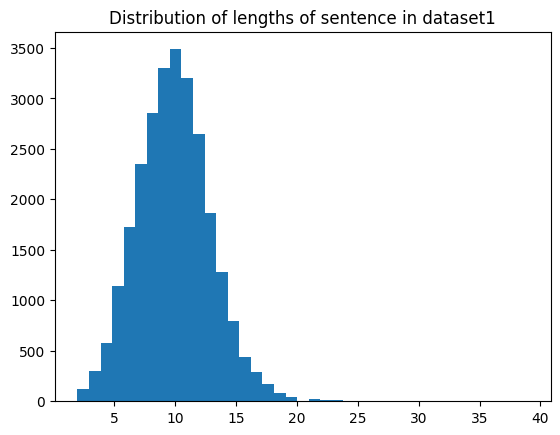

In [8]:
plt.hist(temp1, bins=max(temp1))
plt.title("Distribution of lengths of sentence in dataset1")

Text(0.5, 1.0, 'Distribution of lengths of sentence in dataset2')

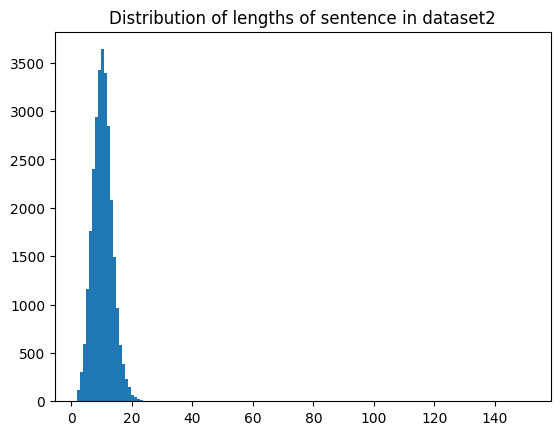

In [9]:
plt.hist(temp, bins=max(temp))
plt.title("Distribution of lengths of sentence in dataset2")

Text(0.5, 1.0, 'Class Distribution')

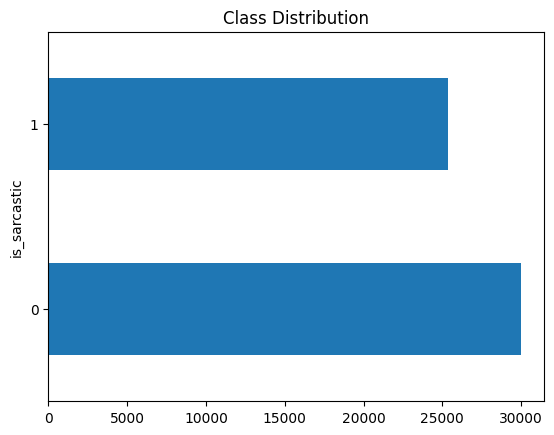

In [10]:
df['is_sarcastic'].value_counts().plot(kind='barh')
plt.title("Class Distribution")

In [13]:
#df = df.drop(['article_link'], axis=1)
df['len'] = df['headline'].apply(lambda x: len(x.split()))

In [14]:
X = np.array(df['headline'])
y = np.array(df['is_sarcastic'])

y = y.reshape((y.shape[0],1))
X = X.squeeze()
m = X.shape[0]
perm = np.random.permutation(m)
X = X[perm]
y = y[perm,:]

X_test = X[:10000]
y_test = y[:10000,:]

X_val = X[10000:20000]
y_val = y[10000:20000,:]

X_train = X[20000:]
y_train = y[20000:,:]

In [15]:

max_len = min(max(len(x.split()) for x in X_train), 20) #25 when used lstm, 98% accuracy
embedding_size = 300
embedding_file = 'crawl-300d-2M.vec'
print("max length:",max_len)

max length: 20


In [16]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(list(X))

X = tokenizer.texts_to_sequences(list(X_train))
X_train = np.array(pad_sequences(X, max_len))

X = tokenizer.texts_to_sequences(list(X_val))
X_val = np.array(pad_sequences(X, max_len))

X = tokenizer.texts_to_sequences(list(X_test))
X_test = np.array(pad_sequences(X, max_len))

print(y_train.shape, X_train.shape)
print(y_val.shape, X_val.shape)
print(y_test.shape, X_test.shape)

(35328, 1) (35328, 20)
(10000, 1) (10000, 20)
(10000, 1) (10000, 20)


In [17]:
word_index = tokenizer.word_index
vocab_size = len(word_index) + 1
print(vocab_size)

30885


In [27]:
def get_indices(word, *arr):
    return word,np.asarray(arr, dtype=np.float32)

word_to_vec = dict(get_indices(*i.rstrip().rsplit()) for i in open(embedding_file))

embedding_matrix_B = np.zeros((vocab_size, embedding_size))

for word,i in word_index.items():
    if i >= vocab_size:
        continue
    embedding_vector = word_to_vec.get(word)
    if embedding_vector is not None:
        embedding_matrix_B[i] = embedding_vector

In [63]:
def baseline():
    vocab_size=30885
    model = tf.keras.Sequential()

    model.add(tf.keras.layers.Embedding(vocab_size,
                                        embedding_size,
                                        input_length=max_len,
                                        weights=[embedding_matrix_B],
                                        trainable=True,
                                        name='Embedding_B'))

    model.add(tf.keras.layers.Conv1D(filters=50,
                                     kernel_size=5,
                                     activation='relu',
                                     name='conv1_B'))
    model.add(tf.keras.layers.MaxPooling1D(2, name='max_pool1_B'))

    model.add(tf.keras.layers.Conv1D(filters=100,
                                     kernel_size=3,
                                     activation='relu',
                                     name='conv2_B'))
    model.add(tf.keras.layers.MaxPooling1D(2, name='max_pool2_B'))
    model.add(tf.keras.layers.Flatten())

    model.add(tf.keras.layers.Dense(100, activation='relu', name='dense1_B'))
    model.add(tf.keras.layers.Dropout(0.5, name='dropout1_B'))
    model.add(tf.keras.layers.Dense(1, activation='sigmoid', name='output_B'))

    return model

In [31]:
print(X_train.dtype, y_train.dtype)
print(X_val.dtype, y_val.dtype)

int32 int64
int32 int64


In [32]:
y_train = y_train.astype('float32')
y_val = y_val.astype('float32')

In [33]:
batch_size = 32
epochs = 10
learning_rate = 5e-5

model = baseline()
checkpointer = ModelCheckpoint(filepath = "/content/gdrive/My Drive/baseline.keras",
                               monitor='val_loss',
                               verbose=1,
                               save_best_only=True,
                               mode='min')

model.compile(loss='binary_crossentropy',
              optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
              metrics=['accuracy', f1_m])

history = model.fit(X_train,
                    y_train,
                    batch_size=batch_size,
                    epochs=epochs,
                    callbacks=[checkpointer],
                    validation_data=(X_val,y_val))

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


1098/1104 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5934 - f1_m: 0.4977 - loss: 0.6569
Epoch 1: val_loss improved from inf to 0.41462, saving model to /content/gdrive/My Drive/baseline.keras
1104/1104 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.5940 - f1_m: 0.4984 - loss: 0.6564 - val_accuracy: 0.8271 - val_f1_m: 0.8163 - val_loss: 0.4146
Epoch 2/10
1095/1104 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8504 - f1_m: 0.8276 - loss: 0.3669
Epoch 2: val_loss improved from 0.41462 to 0.30270, saving model to /content/gdrive/My Drive/baseline.keras
1104/1104 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8505 - f1_m: 0.8277 - loss: 0.3667 - val_accuracy: 0.8725 - val_f1_m: 0.8572 - val_loss: 0.3027
Epoch 3/10
1097/1104 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9033 - f1_m: 0.8910 - loss: 0.2487
Epoch 3: val_loss improved from 0.30270 to 0.25963, saving model to /content/gdrive/My Drive/baseline.keras
1104/1104 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.9033 - f1_m: 0.891

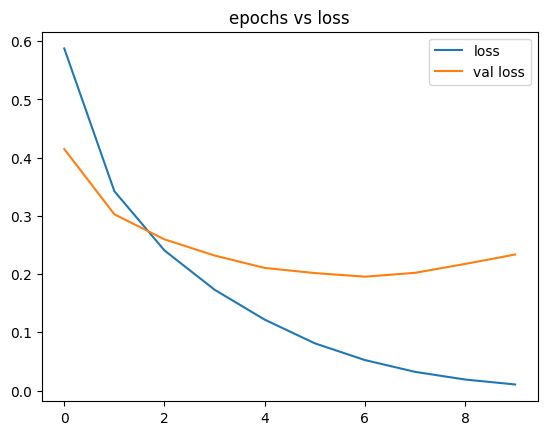

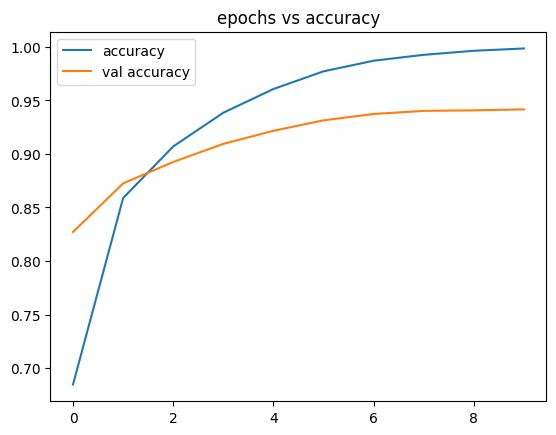

In [36]:
loss = history.history['loss']
val_loss = history.history['val_loss']
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
epoch = history.epoch

plt.plot(epoch,loss, label='loss')
plt.plot(epoch, val_loss, label='val loss')
plt.legend()
plt.title('epochs vs loss')
plt.show()

plt.plot(epoch,acc, label='accuracy')
plt.plot(epoch, val_acc, label='val accuracy')
plt.legend()
plt.title('epochs vs accuracy')
plt.show()

In [39]:
X_train = X_train.astype('float32')
X_val = X_val.astype('float32')

In [41]:
y_train = y_train.astype('float32')
y_val = y_val.astype('float32')
y_test = y_test.astype('float32')


In [42]:
model.load_weights('/content/gdrive/My Drive/baseline.keras')
results = model.evaluate(X_test,
                         y_test,
                         batch_size=batch_size
                         )

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9430 - f1_m: 0.9315 - loss: 0.1878


In [43]:
print("Loss on test set:", results[0])
print("Accuracy on test set:", results[1])
print ("F1 score on test set:", results[2])

Loss on test set: 0.19023291766643524
Accuracy on test set: 0.9409999847412109
F1 score on test set: 0.9319005608558655


In [44]:
y_score = model.predict(X_test, batch_size=1024)
y_preds = model.predict(X_test, batch_size=1024).round().astype(int)

10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 103ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


In [50]:
import sklearn
import sklearn.metrics
import itertools

In [48]:
def plot_roc(fpr,tpr,label= 'ROC curve'):
    plt.plot(fpr, tpr, label = 'ROC curve', linewidth = 2)
    plt.plot([0,1],[0,1], 'k--', linewidth = 2)
   # plt.xlim([0.0,0.001])
   # plt.ylim([0.0,1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.show();
def plot_confusion_matrix(cm, classes,
                          normalize = False,
                          title = 'Confusion matrix"',
                          cmap = plt.cm.Blues) :
    plt.imshow(cm, interpolation = 'nearest', cmap = cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation = 0)
    plt.yticks(tick_marks, classes)

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])) :
        plt.text(j, i, cm[i, j],
                 horizontalalignment = 'center',
                 color = 'white' if cm[i, j] > thresh else 'black')

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

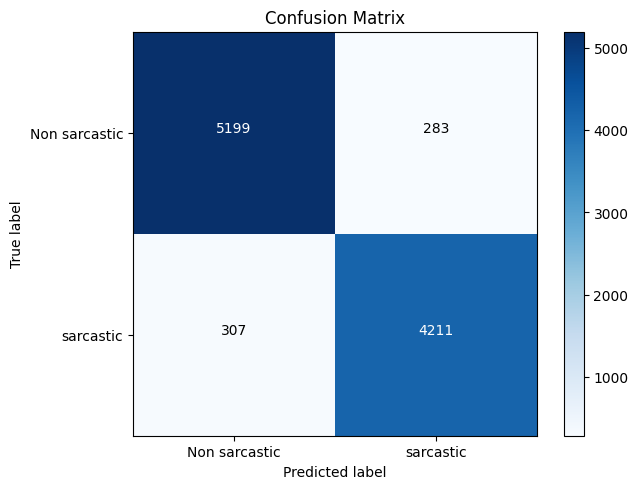

In [51]:
cm=sklearn.metrics.confusion_matrix(y_test, y_preds)
plot_confusion_matrix(cm,classes=['Non sarcastic','sarcastic'],title='Confusion Matrix')

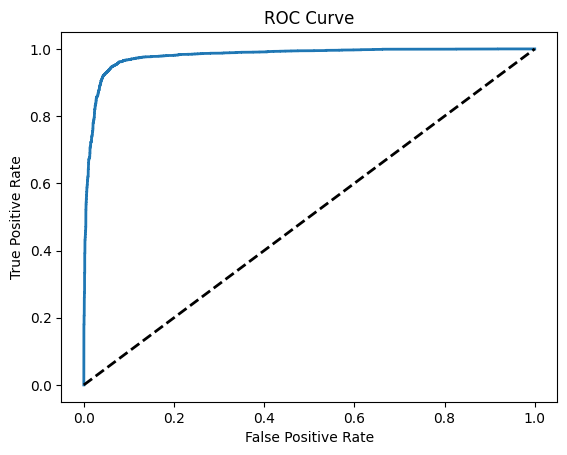

In [52]:
fpr, tpr, t = sklearn.metrics.roc_curve(y_test, y_score)
plot_roc(fpr, tpr,label='ROC curve ')

In [54]:
print("Test accuracy score", sklearn.metrics.accuracy_score(y_test, y_preds))
print('Precision= ',sklearn.metrics.precision_score(y_test, y_preds))
print('Recall= ',sklearn.metrics.recall_score(y_test, y_preds))
print('F1 score= ',sklearn.metrics.f1_score(y_test, y_preds))
from sklearn.metrics import roc_auc_score
print('auc= ',roc_auc_score(y_test,y_score))

Test accuracy score 0.941
Precision=  0.9370271473075211
Recall=  0.932049579459938
F1 score=  0.9345317354638261
auc=  0.9796673293045338


In [56]:
B = baseline()
B.build(input_shape=(None, X_train.shape[1]))
B.load_weights('/content/gdrive/My Drive/baseline.keras')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


**CNN-SVM MODEL**

In [57]:
from sklearn import svm
from mlxtend.plotting import plot_decision_regions
from sklearn.model_selection import learning_curve
from sklearn.metrics import accuracy_score

In [68]:
def baseline():
    vocab_size = 30885
    inputs = tf.keras.Input(shape=(max_len,), name="input_B")

    x = tf.keras.layers.Embedding(vocab_size, embedding_size,
                                  weights=[embedding_matrix_B],
                                  trainable=True,
                                  name='Embedding_B')(inputs)
    x = tf.keras.layers.Conv1D(50, 5, activation='relu', name='conv1_B')(x)
    x = tf.keras.layers.MaxPooling1D(2, name='max_pool1_B')(x)
    x = tf.keras.layers.Conv1D(100, 3, activation='relu', name='conv2_B')(x)
    x = tf.keras.layers.MaxPooling1D(2, name='max_pool2_B')(x)
    x = tf.keras.layers.Flatten()(x)
    x = tf.keras.layers.Dense(100, activation='relu', name='dense1_B')(x)
    x = tf.keras.layers.Dropout(0.5, name='dropout1_B')(x)
    outputs = tf.keras.layers.Dense(1, activation='sigmoid', name='output_B')(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    return model


In [69]:
B = baseline()
B.load_weights('/content/gdrive/My Drive/baseline.keras')

# Now you can safely create a sub-model
m_temp = tf.keras.Model(inputs=B.input, outputs=B.get_layer('dropout1_B').output)
t = m_temp.predict(X_train)
arr = t


1104/1104 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


In [72]:
m_temp = tf.keras.Model(inputs=B.input, outputs=B.get_layer('dropout1_B').output)
t = m_temp.predict(X_train)
arr = K.eval(t)

clf = svm.SVC(kernel='rbf', C=20, gamma=.1,probability=True)

train_sizes, train_scores, valid_scores = learning_curve(clf, arr, y_train.ravel())

clf.fit(arr, y_train.ravel())

1104/1104 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


SVC(C=20, gamma=0.1, probability=True)

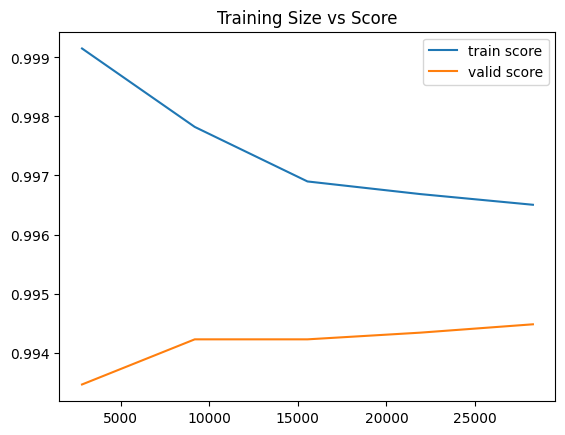

In [73]:
train_scores_mean = np.mean(train_scores, axis=1)
valid_scores_mean = np.mean(valid_scores, axis=1)

plt.plot(train_sizes, train_scores_mean, label='train score')
plt.plot(train_sizes, valid_scores_mean, label='valid score')
plt.legend()
plt.title("Training Size vs Score")
plt.show()


In [74]:
m_temp = tf.keras.Model(inputs=B.input, outputs=B.get_layer('dense1_B').output)
tt = m_temp.predict(X_test)
tt = K.eval(tt)
ans = clf.predict(tt)

tt = m_temp.predict(X_train)
tt = K.eval(tt)
trn = clf.predict(tt)

tt = m_temp.predict(X_val)
tt = K.eval(tt)
val = clf.predict(tt)
print("Train Acc:", accuracy_score(y_train.ravel(), trn))
print("Val Acc:", accuracy_score(y_val.ravel(), val))
print("Test Acc:", accuracy_score(y_test.ravel(), ans))

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
1104/1104 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Train Acc: 0.9964617300724637
Val Acc: 0.9404
Test Acc: 0.9453


In [75]:
m_temp = tf.keras.Model(inputs=B.input, outputs=B.get_layer('dense1_B').output)
tt = m_temp.predict(X_test)
tt = K.eval(tt)
y_score = clf.predict_proba(tt)[:, 1]
y_preds = clf.predict(tt).round().astype(int)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


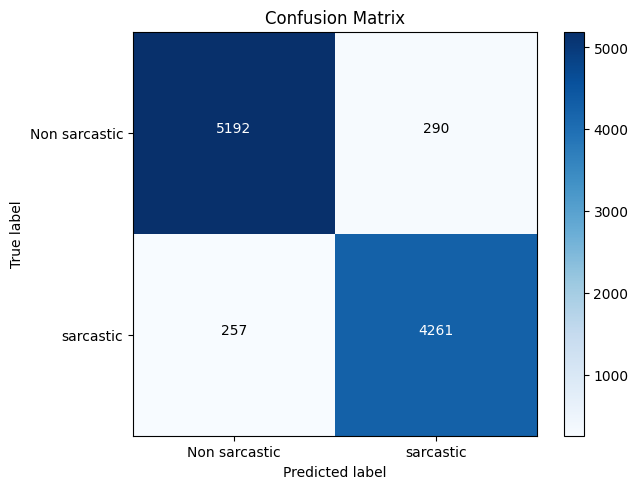

In [76]:
cm=sklearn.metrics.confusion_matrix(y_test, y_preds)
plot_confusion_matrix(cm,classes=['Non sarcastic','sarcastic'],title='Confusion Matrix')

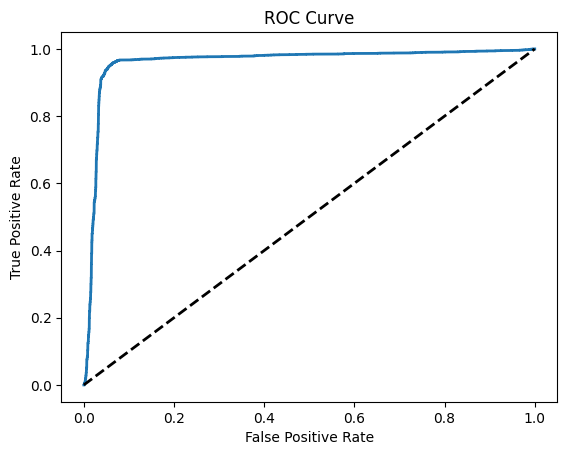

In [77]:

fpr, tpr, t = sklearn.metrics.roc_curve(y_test, y_score)
plot_roc(fpr, tpr,label='ROC curve ')

In [78]:
print("Test accuracy score", sklearn.metrics.accuracy_score(y_test, y_preds))
print('Precision= ',sklearn.metrics.precision_score(y_test, y_preds))
print('Recall= ',sklearn.metrics.recall_score(y_test, y_preds))
print('F1 score= ',sklearn.metrics.f1_score(y_test, y_preds))
from sklearn.metrics import roc_auc_score
print('auc= ',roc_auc_score(y_test,y_score))

Test accuracy score 0.9453
Precision=  0.93627774115579
Recall=  0.9431164231961044
F1 score=  0.9396846399823575
auc=  0.960682423332734
